<a href="https://colab.research.google.com/github/aimachaudhry/507_groupproject_2025/blob/main/part3_viz_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from scipy.stats import linregress

!pip install pymysql

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")
DB_TABLE = os.getenv("DB_TABLE")

print("Loaded from .env:", DB_HOST, DB_USER, DB_NAME)

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")

Loaded from .env: shtm-fallprev.mysql.database.azure.com ahistudent sbu_athletics


In [ ]:
selected_metrics = [
    "Jump Height(m)",
    "Peak Propulsive Force(N)",
    "RSI",
    "accel_load_accum",
    "distance_total"
]

metrics_str = ", ".join([f"'{m}'" for m in selected_metrics])

In [ ]:
from sqlalchemy import text

# We want ONLY Men's Basketball, NOT Women's

# Define patterns to capture both variations of Men's Basketball
mbb_pattern_apostrophe = "%Men's Basketball%"
mbb_pattern_no_apostrophe = "%Mens Basketball%"

# Define patterns to exclude both variations of Women's Basketball
wbb_pattern_apostrophe = "%Women's Basketball%"
wbb_pattern_no_apostrophe = "%Womens Basketball%"

# Modified query to handle both variations of Men's and Women's Basketball
query_team = text(f"""
    SELECT playername, team, metric, value, timestamp
    FROM {DB_TABLE}
    WHERE (team LIKE :mbb_ap OR team LIKE :mbb_no_ap)
      AND (team NOT LIKE :wbb_ap AND team NOT LIKE :wbb_no_ap)
      AND metric IN ({metrics_str})
""")

team_df = pd.read_sql(
    query_team,
    engine,
    params={
        "mbb_ap": mbb_pattern_apostrophe,
        "mbb_no_ap": mbb_pattern_no_apostrophe,
        "wbb_ap": wbb_pattern_apostrophe,
        "wbb_no_ap": wbb_pattern_no_apostrophe
    }
)

team_df["timestamp"] = pd.to_datetime(team_df["timestamp"], errors="coerce")

print("Rows for **Men's Basketball only** + selected metrics:", len(team_df))
team_df["team"].value_counts().head(10)

Rows for **Men's Basketball only** + selected metrics: 27424


,count
team,
Mens Basketball,18448
"Team: Stony Brook Men's Basketball , Team: Men's Basketball 2024-2025",2856
Team: Stony Brook Men's Basketball,2757
"Team: Men's Basketball 2024-2025, Team: Stony Brook Men's Basketball",1305
"Group: Men's Basketball, Group: 21-22, Team: Stony Brook Men's Basketball , Team: Stony Brook",1115
"Group: 21-22, Team: Stony Brook Men's Basketball",566
"Group: Men's Basketball, Team: Stony Brook Men's Basketball , Team: Stony Brook",137
"Group: Men's Basketball, Group: 21-22, Team: Stony Brook, Team: Stony Brook Men's Basketball",132
"Group: Men's Basketball, Team: Stony Brook",75


In [ ]:
TEAM_NAME = "Stony Brook Men's Basketball"
TEAM_NAME

"Stony Brook Men's Basketball"

In [ ]:
metric_count_by_player = (
    team_df.groupby(["playername", "metric"])
           .size()
           .unstack(fill_value=0)
)

print("Metrics per player (first 10 rows):")
metric_count_by_player.head(10)

Metrics per player (first 10 rows):


metric,Jump Height(m),Peak Propulsive Force(N),RSI,accel_load_accum,distance_total
playername,,,,,
PLAYER_002,110,110,110,204,204
PLAYER_006,0,0,0,21,21
PLAYER_008,0,0,0,25,25
PLAYER_027,2,2,2,0,0
PLAYER_032,38,38,38,98,98
PLAYER_038,0,0,0,11,11
PLAYER_047,0,0,0,1,1
PLAYER_051,0,0,0,50,50
PLAYER_066,130,130,130,278,278


In [ ]:
complete_players = metric_count_by_player[
    (metric_count_by_player > 0).all(axis=1)
]

print("Number of players with ALL 5 metrics:", len(complete_players))
complete_players.head(10)

Number of players with ALL 5 metrics: 42


metric,Jump Height(m),Peak Propulsive Force(N),RSI,accel_load_accum,distance_total
playername,,,,,
PLAYER_002,110,110,110,204,204
PLAYER_032,38,38,38,98,98
PLAYER_066,130,130,130,278,278
PLAYER_074,48,48,48,184,184
PLAYER_099,12,12,12,56,56
PLAYER_1036,32,32,32,56,56
PLAYER_1050,30,30,30,55,55
PLAYER_1052,83,83,81,242,242
PLAYER_1079,148,148,147,310,310


In [ ]:
top2 = (
    team_df[team_df["playername"].isin(complete_players.index)]
    .groupby("playername")
    .size()
    .sort_values(ascending=False)
    .head(2)
)

print("Top 2 players with the most records and all 5 metrics:")
print(top2)

top_two_players = list(top2.index)
top_two_players

Top 2 players with the most records and all 5 metrics:
playername
PLAYER_755     1586
PLAYER_1186    1297
dtype: int64


['PLAYER_755', 'PLAYER_1186']

In [ ]:
athlete1 = top_two_players[0]
athlete2 = top_two_players[1]

athlete1, athlete2

('PLAYER_755', 'PLAYER_1186')

In [ ]:
def plot_metric_over_time(df, athlete, metric):
    """
    Plots metric over time for one athlete.
    """
    sub = df[(df["playername"] == athlete) & (df["metric"] == metric)].copy()
    sub = sub.sort_values("timestamp")

    if sub.empty:
        print(f"No data for {athlete} – {metric}")
        return sub

    plt.figure(figsize=(10, 4))
    plt.plot(sub["timestamp"], sub["value"], marker="o")
    plt.title(f"{athlete} – {metric} over time")
    plt.xlabel("Date")
    plt.ylabel(metric)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return sub


def print_best_worst(df, athlete, metric):
    """
    Prints best and worst recorded values for an athlete.
    """
    sub = df[(df["playername"] == athlete) & (df["metric"] == metric)].copy()

    if sub.empty:
        print(f"No data for {athlete} – {metric}")
        return

    best_row = sub.loc[sub["value"].idxmax()]
    worst_row = sub.loc[sub["value"].idxmin()]

    print(f"\n{athlete} – {metric}")
    print(f"  BEST:  {best_row['value']} on {best_row['timestamp'].date()}")
    print(f"  WORST: {worst_row['value']} on {worst_row['timestamp'].date()}")


def trend_analysis(df, athlete, metric):
    """
    Runs simple linear regression to identify improving/declining trends.
    """
    sub = df[(df["playername"] == athlete) & (df["metric"] == metric)].copy()
    sub = sub.sort_values("timestamp")

    if len(sub) < 2:
        print(f"Not enough data for trend: {athlete} – {metric}")
        return

    # x = days since first measurement
    x = (sub["timestamp"] - sub["timestamp"].min()).dt.days
    y = sub["value"]

    slope, intercept, r, p, stderr = linregress(x, y)

    print(f"\nTrend for {athlete} – {metric}")
    print(f"  Slope: {slope:.4f}")
    print(f"  R: {r:.3f}, p: {p:.4f}")

    if slope > 0:
        print("  📈Interpretation: Improving over time")
    elif slope < 0:
        print("  📉Interpretation: Declining over time")
    else:
        print("  No clear trend.")


Analysis for PLAYER_755 – Stony Brook Men's Basketball

--- Jump Height(m) ---


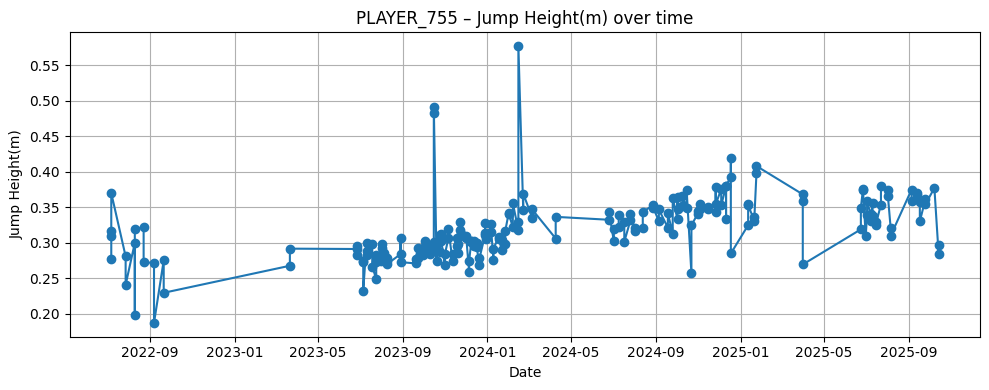


PLAYER_755 – Jump Height(m)
  BEST:  0.5771 on 2024-02-14
  WORST: 0.1872 on 2022-09-06

Trend for PLAYER_755 – Jump Height(m)
  Slope: 0.0001
  R: 0.543, p: 0.0000
  📈Interpretation: Improving over time

--- Peak Propulsive Force(N) ---


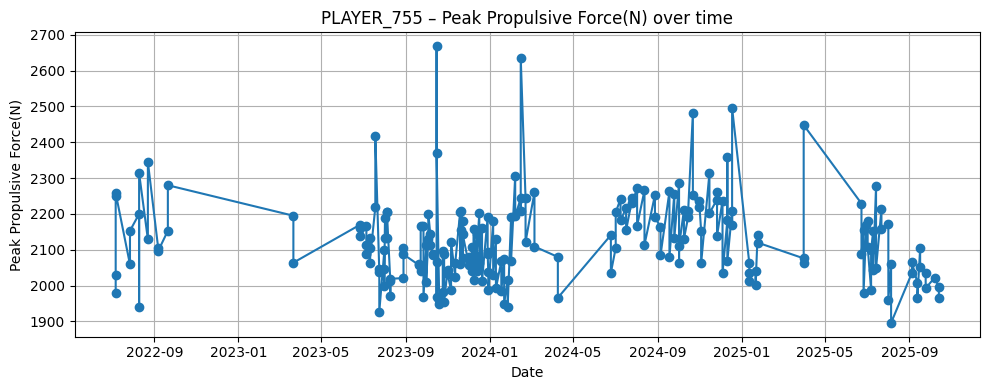


PLAYER_755 – Peak Propulsive Force(N)
  BEST:  2668.0 on 2023-10-15
  WORST: 1896.0 on 2025-08-05

Trend for PLAYER_755 – Peak Propulsive Force(N)
  Slope: -0.0041
  R: -0.011, p: 0.8787
  📉Interpretation: Declining over time

--- RSI ---


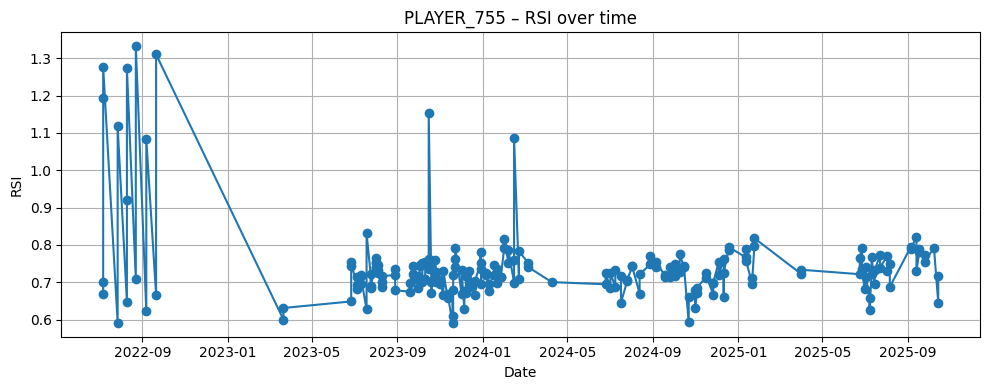


PLAYER_755 – RSI
  BEST:  1.3325 on 2022-08-22
  WORST: 0.5912 on 2023-11-18

Trend for PLAYER_755 – RSI
  Slope: -0.0001
  R: -0.226, p: 0.0010
  📉Interpretation: Declining over time

--- accel_load_accum ---


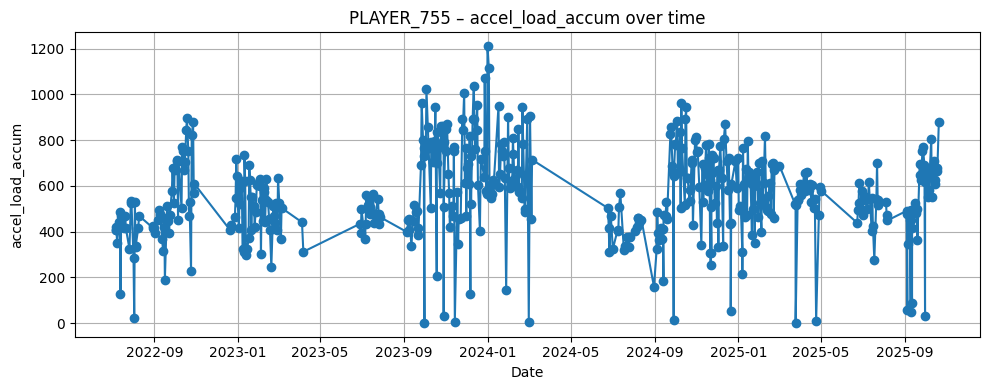


PLAYER_755 – accel_load_accum
  BEST:  1210.568546 on 2023-12-31
  WORST: 0.627932 on 2023-09-30

Trend for PLAYER_755 – accel_load_accum
  Slope: 0.0346
  R: 0.064, p: 0.1655
  📈Interpretation: Improving over time

--- distance_total ---


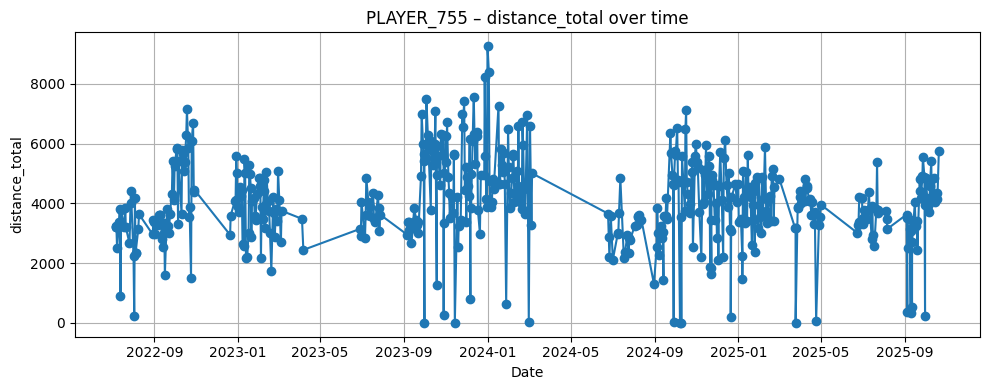


PLAYER_755 – distance_total
  BEST:  9256.827734 on 2023-12-31
  WORST: 0.0 on 2024-10-07

Trend for PLAYER_755 – distance_total
  Slope: -0.2041
  R: -0.050, p: 0.2722
  📉Interpretation: Declining over time

Analysis for PLAYER_1186 – Stony Brook Men's Basketball

--- Jump Height(m) ---


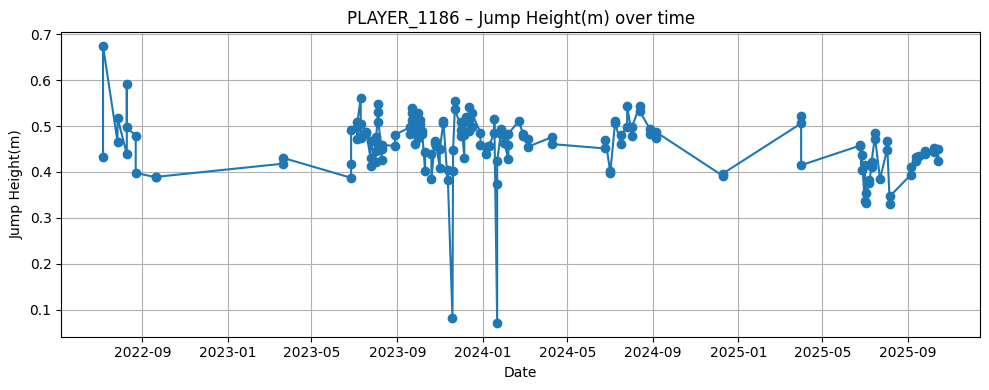


PLAYER_1186 – Jump Height(m)
  BEST:  0.6736 on 2022-07-06
  WORST: 0.0719 on 2024-01-21

Trend for PLAYER_1186 – Jump Height(m)
  Slope: -0.0001
  R: -0.262, p: 0.0006
  📉Interpretation: Declining over time

--- Peak Propulsive Force(N) ---


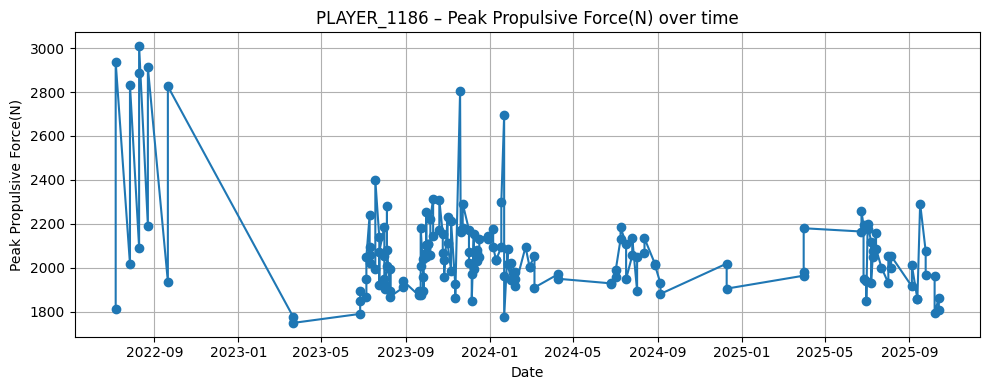


PLAYER_1186 – Peak Propulsive Force(N)
  BEST:  3009.0 on 2022-08-09
  WORST: 1749.0 on 2023-03-21

Trend for PLAYER_1186 – Peak Propulsive Force(N)
  Slope: -0.2171
  R: -0.303, p: 0.0001
  📉Interpretation: Declining over time

--- RSI ---


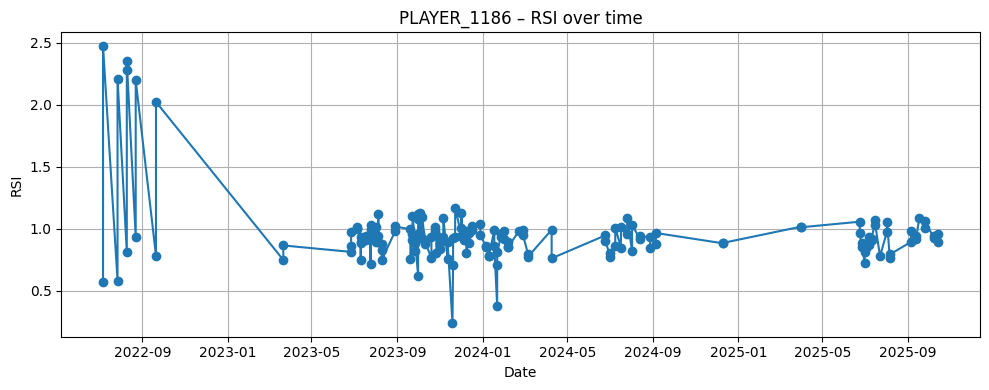


PLAYER_1186 – RSI
  BEST:  2.4731 on 2022-07-06
  WORST: 0.2388 on 2023-11-18

Trend for PLAYER_1186 – RSI
  Slope: -0.0003
  R: -0.269, p: 0.0005
  📉Interpretation: Declining over time

--- accel_load_accum ---


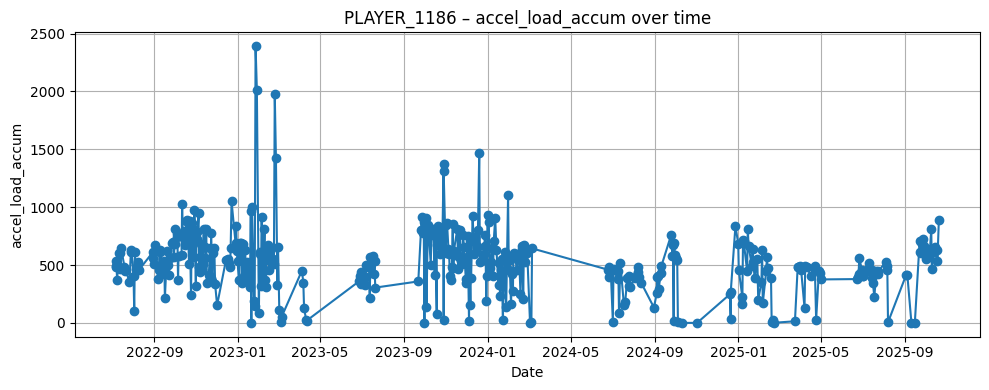


PLAYER_1186 – accel_load_accum
  BEST:  2391.677839 on 2023-01-26
  WORST: 0.007487 on 2024-10-10

Trend for PLAYER_1186 – accel_load_accum
  Slope: -0.1478
  R: -0.190, p: 0.0001
  📉Interpretation: Declining over time

--- distance_total ---


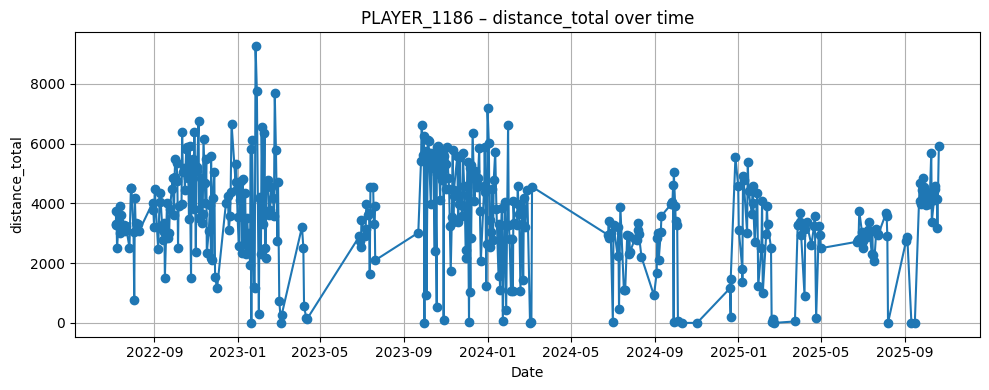


PLAYER_1186 – distance_total
  BEST:  9266.115512 on 2023-01-26
  WORST: 0.0 on 2023-01-20

Trend for PLAYER_1186 – distance_total
  Slope: -0.8806
  R: -0.194, p: 0.0001
  📉Interpretation: Declining over time


In [ ]:
# Run full analysis for both athletes
for athlete in [athlete1, athlete2]:
    print("\n" + "="*60)
    print(f"Analysis for {athlete} – {TEAM_NAME}")
    print("="*60)

    for metric in selected_metrics:
        print(f"\n--- {metric} ---")

        # Plot
        _ = plot_metric_over_time(team_df, athlete, metric)

        # Best & Worst
        print_best_worst(team_df, athlete, metric)

        # Trend analysis
        trend_analysis(team_df, athlete, metric)

In [ ]:
team_df["metric"].value_counts()

,count
metric,
accel_load_accum,9224
distance_total,9224
Jump Height(m),2999
Peak Propulsive Force(N),2999
RSI,2978
